# ⚡ PowerCo — Feature Engineering Pipeline
## Task 4 | BCG Data Science Job Simulation

**Objective:** Transform the cleaned EDA output into a model-ready feature matrix.

**Input:** `clean_data_after_eda.csv` + `price_data.csv`

**Output:** `data_for_predictions.csv` — 62 features + 1 target (`churn`)

### Table of Contents
| # | Section |
|---|----|
| 1 | Import Packages |
| 2 | Load & Parse Data |
| 3 | Price Diff Features (from price_data) |
| 4 | Date & Tenure Features |
| 5 | Log-Transform Skewed Columns |
| 6 | Categorical Encoding |
| 7 | Feature Summary & Correlation |
| 8 | Export Final Dataset |

## 1. Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

print('✅ Packages loaded.')

✅ Packages loaded.


## 2. Load & Parse Data

In [2]:
# ── Main customer dataset ─────────────────────────────────────────────────────
df = pd.read_csv('./clean_data_after_eda.csv')

DATE_COLS = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in DATE_COLS:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d')

print(f'Shape          : {df.shape}')
print(f'Churn rate     : {df["churn"].mean() * 100:.2f}%  ({df["churn"].sum():,} churned)')
df.head(3)

Shape          : (14606, 44)
Churn rate     : 9.72%  (1,419 churned)


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,var_year_price_off_peak_var,var_year_price_peak_var,var_year_price_mid_peak_var,var_year_price_off_peak_fix,var_year_price_peak_fix,var_year_price_mid_peak_fix,var_year_price_off_peak,var_year_price_peak,var_year_price_mid_peak,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0000,0,0.0000,1.7800,0.1145,0.0981,40.6067,t,0.0000,25.4400,25.4400,2,678.9900,3,lxidpiddsbxsbosboudacockeimpuepw,43.6480,0.0001,0.0000,0.0004,1.1028,49.5507,22.0225,1.1028,49.5507,22.0230,0.0001,0.0000,0.0009,2.0863,99.5305,44.2358,2.0864,99.5306,44.2367,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.9500,0,0.0000,16.2700,0.1457,0.0000,44.3114,f,0.0000,16.3800,16.3800,1,18.8900,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.8000,0.0000,0.0006,0.0000,0.0065,0.0000,0.0000,0.0065,0.0006,0.0000,0.0000,0.0012,0.0000,0.0095,0.0000,0.0000,0.0095,0.0012,0.0000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.9600,0,0.0000,38.7200,0.1658,0.0879,44.3114,f,0.0000,28.6000,28.6000,1,6.6000,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.8560,0.0000,0.0000,0.0000,0.0077,0.0000,0.0000,0.0077,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0


In [3]:
# ── Price data ────────────────────────────────────────────────────────────────
price_df = pd.read_csv('./price_data.csv')
price_df['price_date'] = pd.to_datetime(price_df['price_date'])

print(f'Price data shape : {price_df.shape}')
print(f'Date range       : {price_df["price_date"].min().date()} → {price_df["price_date"].max().date()}')
print(f'Unique customers : {price_df["id"].nunique():,}')
price_df.head(3)

Price data shape : (193002, 8)
Date range       : 2015-01-01 → 2015-12-01
Unique customers : 16,096


,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.1514,0.0000,0.0000,44.2669,0.0000,0.0000
1,038af19179925da21a25619c5a24b745,2015-02-01,0.1514,0.0000,0.0000,44.2669,0.0000,0.0000
2,038af19179925da21a25619c5a24b745,2015-03-01,0.1514,0.0000,0.0000,44.2669,0.0000,0.0000


## 3. Price Diff Features

**Hypothesis:** Customers who pay significantly more in peak vs off-peak periods, or who see volatile pricing across months, are more exposed to competitive switching.

We compute **three groups** of price features from `price_data.csv`:

| Group | Description |
|---|---|
| Dec–Jan off-peak diff | Spread between December and January off-peak prices (energy + power) |
| Mean period diffs (×6) | Average difference between each pair of tariff period types across all months |
| Max monthly diffs (×6) | Largest single-month difference between each pair — captures peak exposure |

### 3.1 Dec vs Jan Off-Peak Price Difference

In [4]:
# Group monthly prices per customer
monthly = (
    price_df
    .groupby(['id', 'price_date'])[['price_off_peak_var', 'price_off_peak_fix']]
    .mean()
    .reset_index()
)

# First record = January (earliest), Last record = December (latest)
jan = monthly.groupby('id').first().reset_index()
dec = monthly.groupby('id').last().reset_index()

diff = pd.merge(
    dec.rename(columns={'price_off_peak_var': 'dec_var', 'price_off_peak_fix': 'dec_fix'}),
    jan[['id', 'price_off_peak_var', 'price_off_peak_fix']],
    on='id'
)
diff['offpeak_diff_dec_january_energy'] = diff['dec_var'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power']  = diff['dec_fix'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy', 'offpeak_diff_dec_january_power']]

df = df.merge(diff, on='id', how='left')
print('✅ Dec–Jan off-peak diff features added.')
diff[['offpeak_diff_dec_january_energy', 'offpeak_diff_dec_january_power']].describe()

✅ Dec–Jan off-peak diff features added.


,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
count,16096.0000,16096.0000
mean,-0.0045,0.2795
std,0.0128,1.4328
min,-0.1485,-44.2669
25%,-0.0082,0.0000
50%,-0.0056,0.1629
75%,-0.0036,0.1778
max,0.1690,40.7289


### 3.2 Mean Diff Features — Average Spread Across All Months

In [5]:
mean_prices = (
    price_df
    .groupby('id')[['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
                    'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']]
    .mean()
    .reset_index()
)

# Variable component diffs
mean_prices['off_peak_peak_var_mean_diff']      = mean_prices['price_off_peak_var'] - mean_prices['price_peak_var']
mean_prices['peak_mid_peak_var_mean_diff']       = mean_prices['price_peak_var']     - mean_prices['price_mid_peak_var']
mean_prices['off_peak_mid_peak_var_mean_diff']   = mean_prices['price_off_peak_var'] - mean_prices['price_mid_peak_var']

# Fixed component diffs
mean_prices['off_peak_peak_fix_mean_diff']       = mean_prices['price_off_peak_fix'] - mean_prices['price_peak_fix']
mean_prices['peak_mid_peak_fix_mean_diff']        = mean_prices['price_peak_fix']     - mean_prices['price_mid_peak_fix']
mean_prices['off_peak_mid_peak_fix_mean_diff']   = mean_prices['price_off_peak_fix'] - mean_prices['price_mid_peak_fix']

MEAN_DIFF_COLS = [
    'off_peak_peak_var_mean_diff', 'peak_mid_peak_var_mean_diff', 'off_peak_mid_peak_var_mean_diff',
    'off_peak_peak_fix_mean_diff', 'peak_mid_peak_fix_mean_diff', 'off_peak_mid_peak_fix_mean_diff'
]

df = df.merge(mean_prices[['id'] + MEAN_DIFF_COLS], on='id', how='left')
print('✅ 6 mean-diff features added.')
df[MEAN_DIFF_COLS].describe()

✅ 6 mean-diff features added.


,off_peak_peak_var_mean_diff,peak_mid_peak_var_mean_diff,off_peak_mid_peak_var_mean_diff,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff
count,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000
mean,0.0903,0.0238,0.1141,33.4680,3.3632,36.8312
std,0.0609,0.0289,0.0526,13.8231,4.8162,10.2281
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0205,0.0000,0.0507,16.2753,0.0000,24.4129
50%,0.0820,0.0290,0.1474,44.2669,0.0000,44.2817
75%,0.1487,0.0304,0.1502,44.3651,8.1213,44.3706
max,0.2781,0.1963,0.2781,59.2862,28.1230,59.2862


### 3.3 Max Monthly Diff Features — Peak Exposure in Any Single Month

In [6]:
price_df['off_peak_peak_var_diff']       = price_df['price_off_peak_var'] - price_df['price_peak_var']
price_df['peak_mid_peak_var_diff']        = price_df['price_peak_var']     - price_df['price_mid_peak_var']
price_df['off_peak_mid_peak_var_diff']    = price_df['price_off_peak_var'] - price_df['price_mid_peak_var']
price_df['off_peak_peak_fix_diff']        = price_df['price_off_peak_fix'] - price_df['price_peak_fix']
price_df['peak_mid_peak_fix_diff']        = price_df['price_peak_fix']     - price_df['price_mid_peak_fix']
price_df['off_peak_mid_peak_fix_diff']    = price_df['price_off_peak_fix'] - price_df['price_mid_peak_fix']

MONTHLY_DIFF_COLS = [
    'off_peak_peak_var_diff', 'peak_mid_peak_var_diff', 'off_peak_mid_peak_var_diff',
    'off_peak_peak_fix_diff', 'peak_mid_peak_fix_diff', 'off_peak_mid_peak_fix_diff'
]

max_diffs = price_df.groupby('id')[MONTHLY_DIFF_COLS].max().reset_index()
max_diffs.columns = ['id'] + [c.replace('_diff', '_max_monthly_diff') for c in MONTHLY_DIFF_COLS]

MAX_DIFF_COLS = [c for c in max_diffs.columns if c != 'id']
df = df.merge(max_diffs, on='id', how='left')
print('✅ 6 max-monthly-diff features added.')
df[MAX_DIFF_COLS].describe()

✅ 6 max-monthly-diff features added.


,off_peak_peak_var_max_monthly_diff,peak_mid_peak_var_max_monthly_diff,off_peak_mid_peak_var_max_monthly_diff,off_peak_peak_fix_max_monthly_diff,peak_mid_peak_fix_max_monthly_diff,off_peak_mid_peak_fix_max_monthly_diff
count,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000
mean,0.0943,0.0294,0.1199,34.2798,3.4148,37.4468
std,0.0615,0.0330,0.0521,13.8573,4.8647,10.2674
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0226,0.0000,0.0547,16.2916,0.0000,24.4373
50%,0.0846,0.0319,0.1496,44.2669,0.0000,44.4447
75%,0.1514,0.0337,0.1524,44.4447,8.1458,44.4447
max,0.2807,0.2298,0.2807,59.4447,28.1230,59.4447


### 3.4 Visualise Price Features vs Churn

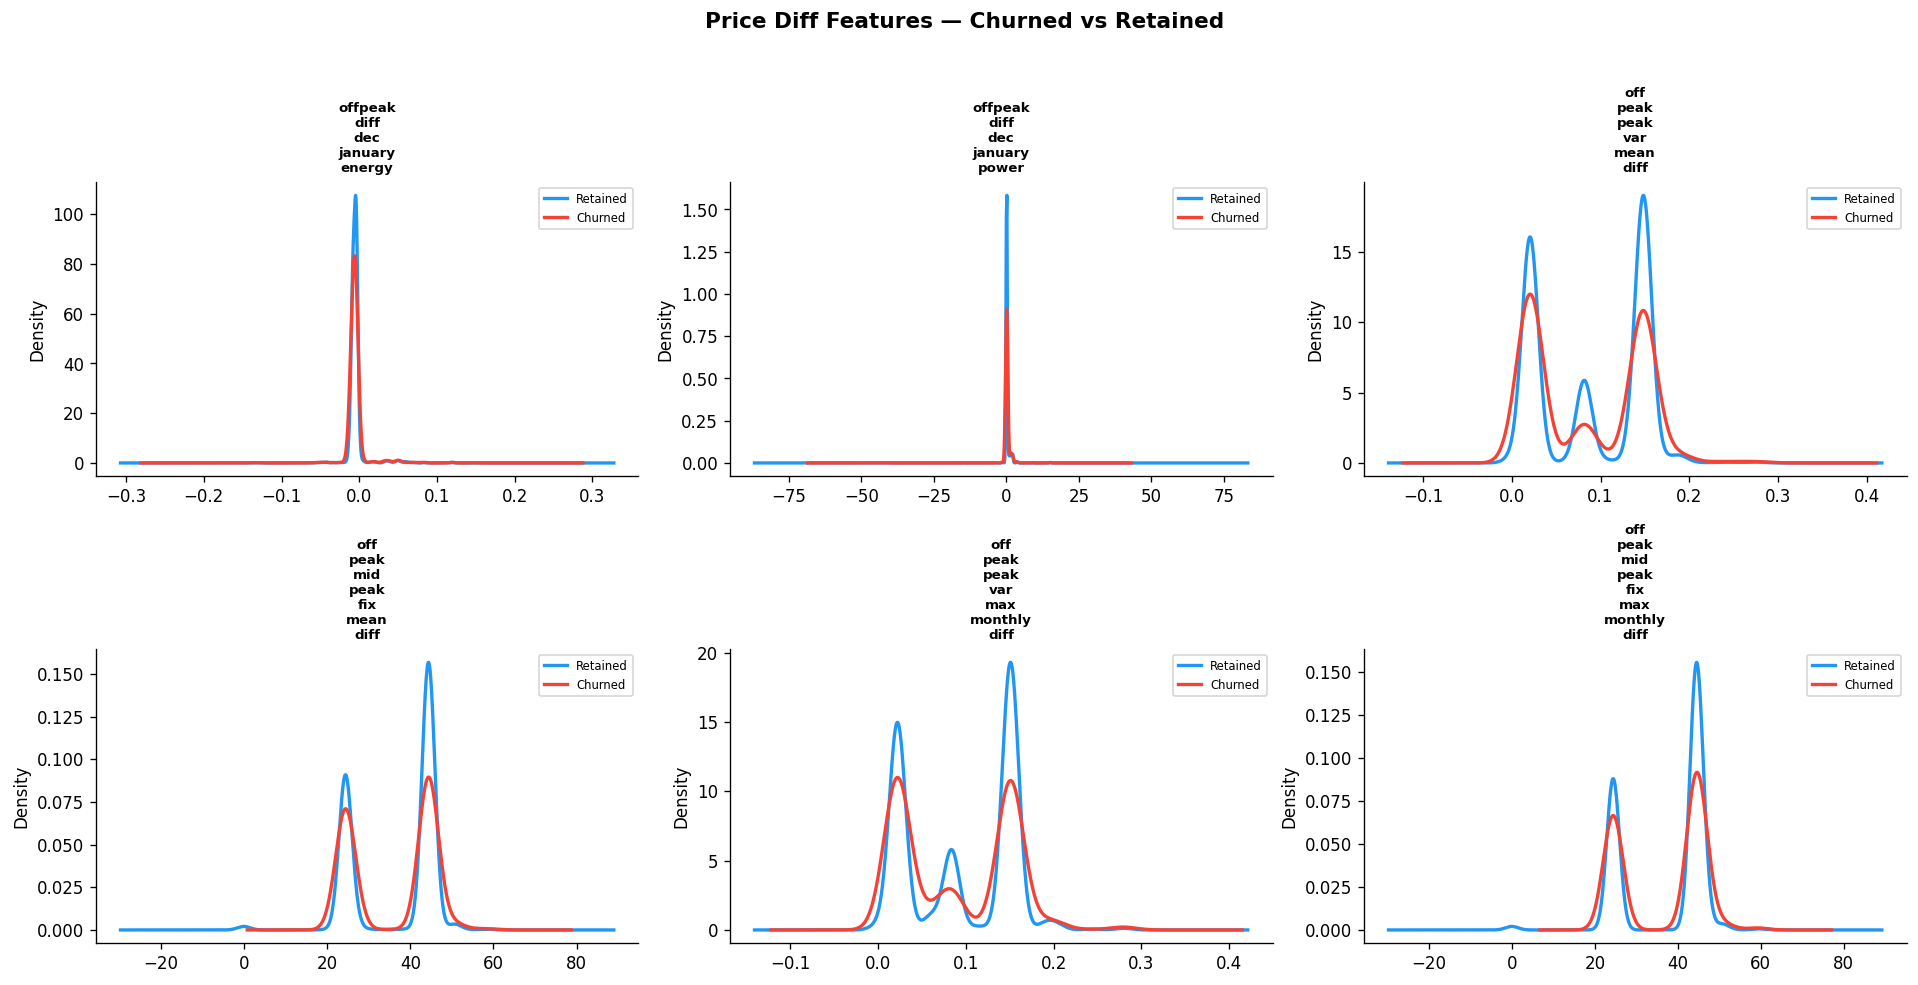

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

plot_feats = [
    'offpeak_diff_dec_january_energy', 'offpeak_diff_dec_january_power',
    'off_peak_peak_var_mean_diff',     'off_peak_mid_peak_fix_mean_diff',
    'off_peak_peak_var_max_monthly_diff', 'off_peak_mid_peak_fix_max_monthly_diff',
]

for i, feat in enumerate(plot_feats):
    ax = axes[i]
    for label, color in [(0, '#2196F3'), (1, '#F44336')]:
        data = df.loc[df['churn'] == label, feat].dropna()
        data.plot.kde(ax=ax, label='Retained' if label == 0 else 'Churned', color=color, lw=2)
    ax.set_title(feat.replace('_', '\n'), fontsize=8, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_xlabel('')

plt.suptitle('Price Diff Features — Churned vs Retained', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Date & Tenure Features

**Hypothesis:** Customers close to contract end, with longer tenure, or whose product was recently modified behave differently regarding churn.

**Reference date:** `2016-01-01` — the snapshot point representing 'today' at prediction time.

| Feature | Formula | Unit |
|---|---|---|
| tenure | (date_end − date_activ) / 365.25 | years (int) |
| months_activ | (ref − date_activ) / 30.44 | months (int) |
| months_to_end | (date_end − ref) / 30.44 | months (int) |
| months_modif_prod | (ref − date_modif_prod) / 30.44 | months (int) |
| months_renewal | (ref − date_renewal) / 30.44 | months (int) |

In [8]:
REFERENCE_DATE = pd.Timestamp('2016-01-01')

df['tenure']          = ((df['date_end']        - df['date_activ'])      .dt.days / 365.25).astype(int)
df['months_activ']    = ((REFERENCE_DATE         - df['date_activ'])      .dt.days / 30.44).astype(int)
df['months_to_end']   = ((df['date_end']        - REFERENCE_DATE)         .dt.days / 30.44).astype(int)
df['months_modif_prod'] = ((REFERENCE_DATE       - df['date_modif_prod']) .dt.days / 30.44).astype(int)
df['months_renewal']  = ((REFERENCE_DATE         - df['date_renewal'])    .dt.days / 30.44).astype(int)

DATE_FEATURES = ['tenure', 'months_activ', 'months_to_end', 'months_modif_prod', 'months_renewal']
print('✅ 5 date/tenure features created.')
df[DATE_FEATURES].describe()

✅ 5 date/tenure features created.


,tenure,months_activ,months_to_end,months_modif_prod,months_renewal
count,14606.0000,14606.0000,14606.0000,14606.0000,14606.0000
mean,5.3180,58.5589,6.3935,35.4595,4.9105
std,1.6959,19.3626,3.5130,30.2439,3.7959
min,2.0000,15.0000,0.0000,0.0000,0.0000
25%,4.0000,44.0000,3.0000,6.0000,2.0000
50%,5.0000,57.0000,6.0000,30.0000,5.0000
75%,6.0000,71.0000,9.0000,64.0000,8.0000
max,13.0000,151.0000,17.0000,151.0000,30.0000


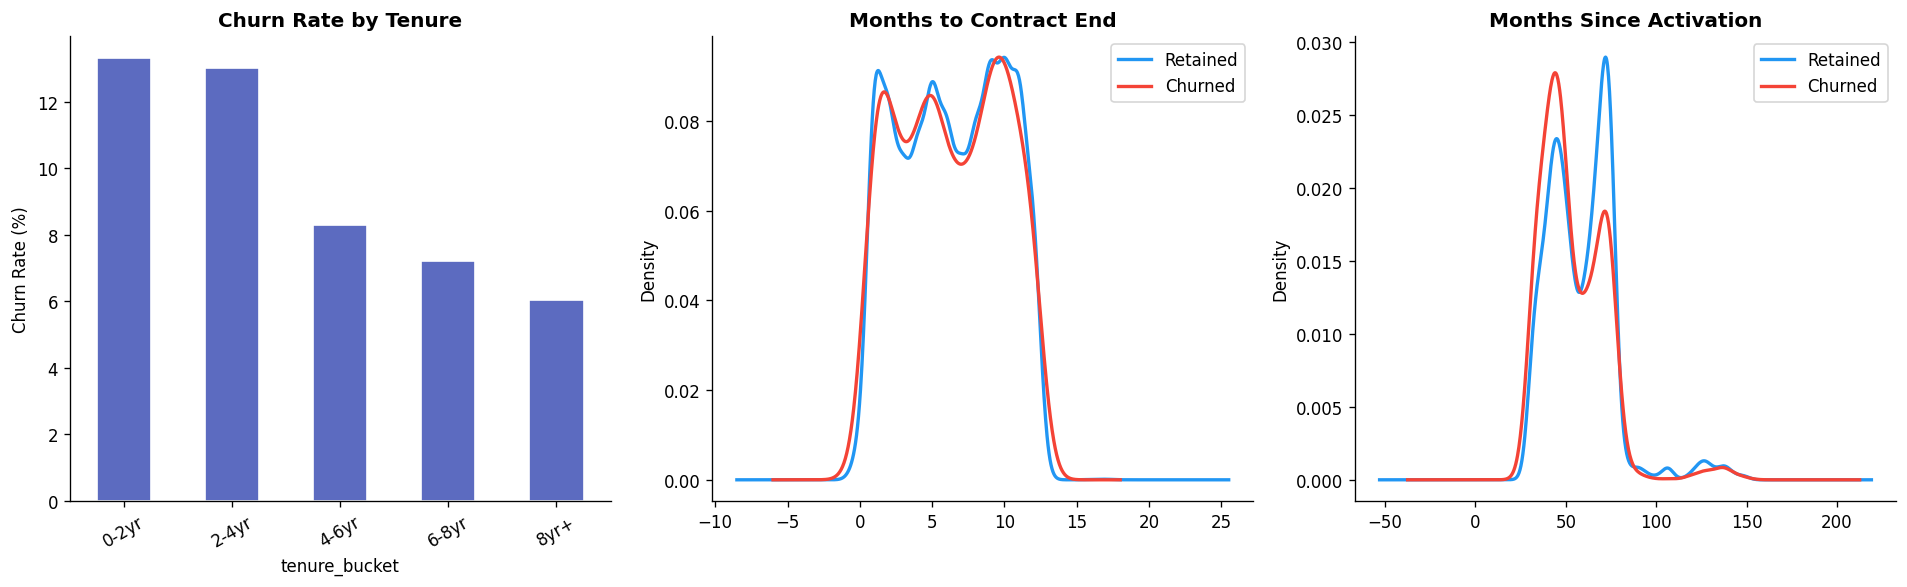

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Churn rate by tenure bucket
df['tenure_bucket'] = pd.cut(df['tenure'], bins=[0, 2, 4, 6, 8, 15],
                              labels=['0-2yr', '2-4yr', '4-6yr', '6-8yr', '8yr+'])
df.groupby('tenure_bucket')['churn'].mean().mul(100).plot(
    kind='bar', ax=axes[0], color='#5C6BC0', edgecolor='white')
axes[0].set_title('Churn Rate by Tenure', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

for label, color in [(0, '#2196F3'), (1, '#F44336')]:
    df.loc[df['churn'] == label, 'months_to_end'].plot.kde(
        ax=axes[1], label='Retained' if label == 0 else 'Churned', color=color, lw=2)
axes[1].set_title('Months to Contract End', fontweight='bold')
axes[1].legend()

for label, color in [(0, '#2196F3'), (1, '#F44336')]:
    df.loc[df['churn'] == label, 'months_activ'].plot.kde(
        ax=axes[2], label='Retained' if label == 0 else 'Churned', color=color, lw=2)
axes[2].set_title('Months Since Activation', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

df.drop(columns=['tenure_bucket'], inplace=True)

## 5. Log-Transform Skewed Columns

As identified in Task 3 EDA, several consumption and financial columns are **heavily right-skewed**. To meet the normality assumptions often expected by ML algorithms (and to give tree-based models cleaner splits), we apply `np.log1p()` — which handles zeros safely.

> **`log1p(x)` = log(1 + x)** — maps zero to zero, handles all non-negative values without error.

Columns to transform: `cons_12m`, `cons_gas_12m`, `cons_last_month`, `imp_cons`, `net_margin`, `forecast_cons_12m`, `forecast_meter_rent_12m`

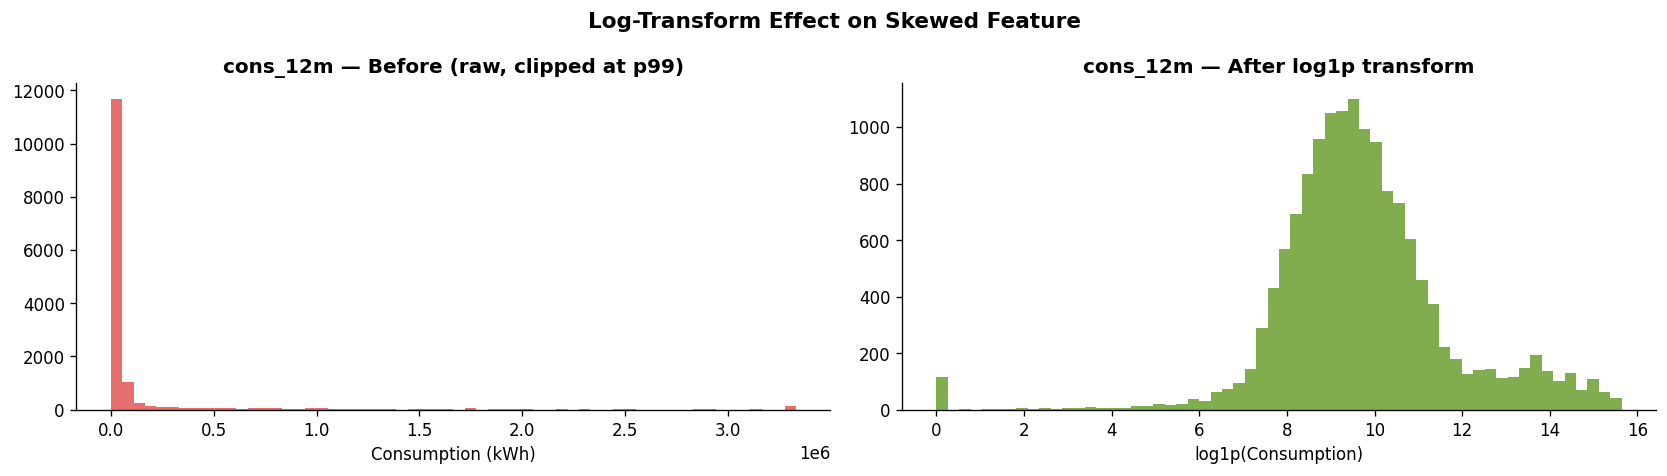

✅ log1p transform applied to: ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'net_margin', 'forecast_cons_12m', 'forecast_meter_rent_12m']


In [10]:
SKEWED_COLS = [
    'cons_12m', 'cons_gas_12m', 'cons_last_month',
    'imp_cons', 'net_margin',
    'forecast_cons_12m', 'forecast_meter_rent_12m'
]
SKEWED_COLS = [c for c in SKEWED_COLS if c in df.columns]

# Show before/after for one column
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['cons_12m'].clip(upper=df['cons_12m'].quantile(0.99)), bins=60,
             color='#E24B4A', edgecolor='none', alpha=0.8)
axes[0].set_title('cons_12m — Before (raw, clipped at p99)', fontweight='bold')
axes[0].set_xlabel('Consumption (kWh)')

# Apply log1p transform
for col in SKEWED_COLS:
    df[col] = np.log1p(df[col])

axes[1].hist(df['cons_12m'], bins=60, color='#639922', edgecolor='none', alpha=0.8)
axes[1].set_title('cons_12m — After log1p transform', fontweight='bold')
axes[1].set_xlabel('log1p(Consumption)')

plt.suptitle('Log-Transform Effect on Skewed Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'✅ log1p transform applied to: {SKEWED_COLS}')

## 6. Categorical Encoding

Three categorical columns are encoded for modelling:

| Column | Approach | Notes |
|---|---|---|
| has_gas | Binary | t/f → 1/0 |
| channel_sales | Rename → `channel`, fill NaN → MISSING, one-hot | Drop 3 rare categories (<12 customers each) |
| origin_up | Fill NaN → MISSING, one-hot | Drop 3 rare categories (<65 customers each) |

In [11]:
# ── 6.1 has_gas: 't'/'f' string → integer 1/0 ───────────────────────────────
df['has_gas'] = (df['has_gas'].astype(str).str.strip().str.lower() == 't').astype(int)
print('has_gas value counts after encoding:')
print(df['has_gas'].value_counts())

has_gas value counts after encoding:
has_gas
0    11955
1     2651
Name: count, dtype: int64


In [12]:
# ── 6.2 channel_sales: fill NaN, rename, one-hot encode ──────────────────────
df['channel_sales'] = df['channel_sales'].fillna('MISSING')
print('channel_sales distribution:')
print(df['channel_sales'].value_counts())

channel_sales distribution:
channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64


In [13]:
# ── 6.3 origin_up: fill NaN ────────────────────────────────────────────────
df['origin_up'] = df['origin_up'].fillna('MISSING')
print('origin_up distribution:')
print(df['origin_up'].value_counts())

origin_up distribution:
origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64


In [14]:
# ── 6.4 Rename channel_sales → channel, then one-hot encode both columns ──────
df = df.rename(columns={'channel_sales': 'channel'})
df = pd.get_dummies(df, columns=['channel', 'origin_up'], drop_first=False, dtype=int)

# ── 6.5 Drop rare channel categories (fewer than ~12 customers) ───────────────
rare_channel = [
    'channel_sddiedcslfslkckwlfkdpoeeailfpeds',
    'channel_epumfxlbckeskwekxbiuasklxalciiuu',
    'channel_fixdbufsefwooaasfcxdxadsiekoceaa',
]
df.drop(columns=[c for c in rare_channel if c in df.columns], inplace=True)

# ── 6.6 Drop rare origin_up categories ────────────────────────────────────────
rare_origin = [
    'origin_up_MISSING',
    'origin_up_ewxeelcelemmiwuafmddpobolfuxioce',
    'origin_up_usapbepcfoloekilkwsdiboslwaxobdp',
]
df.drop(columns=[c for c in rare_origin if c in df.columns], inplace=True)

channel_dummies = [c for c in df.columns if c.startswith('channel_')]
origin_dummies  = [c for c in df.columns if c.startswith('origin_up_')]
print(f'✅ Channel dummies kept  : {channel_dummies}')
print(f'✅ Origin_up dummies kept: {origin_dummies}')

✅ Channel dummies kept  : ['channel_MISSING', 'channel_ewpakwlliwisiwduibdlfmalxowmwpci', 'channel_foosdfpfkusacimwkcsosbicdxkicaua', 'channel_lmkebamcaaclubfxadlmueccxoimlema', 'channel_usilxuppasemubllopkaafesmlibmsdf']
✅ Origin_up dummies kept: ['origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws', 'origin_up_ldkssxwpmemidmecebumciepifcamkci', 'origin_up_lxidpiddsbxsbosboudacockeimpuepw']


## 7. Feature Summary & Correlation

In [15]:
# ── Drop raw date columns and unused columns ─────────────────────────────────
cols_to_drop = DATE_COLS + [c for c in ['forecast_cons_year', 'num_years_antig'] if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print('=' * 55)
print('FEATURE ENGINEERING SUMMARY')
print('=' * 55)
print(f'  Rows               : {df.shape[0]:,}')
print(f'  Total columns      : {df.shape[1]}  (incl. target)')
print(f'  Feature columns    : {df.shape[1] - 1}')
print(f'  Churn rate         : {df["churn"].mean() * 100:.2f}%')
print(f'  Missing values     : {df.isnull().sum().sum()}')
print('=' * 55)
print()
print('All columns:')
for i, col in enumerate(df.columns, 1):
    print(f'{i:>3}. {col}')

FEATURE ENGINEERING SUMMARY
  Rows               : 14,606
  Total columns      : 63  (incl. target)
  Feature columns    : 62
  Churn rate         : 9.72%
  Missing values     : 0

All columns:
  1. id
  2. cons_12m
  3. cons_gas_12m
  4. cons_last_month
  5. forecast_cons_12m
  6. forecast_discount_energy
  7. forecast_meter_rent_12m
  8. forecast_price_energy_off_peak
  9. forecast_price_energy_peak
 10. forecast_price_pow_off_peak
 11. has_gas
 12. imp_cons
 13. margin_gross_pow_ele
 14. margin_net_pow_ele
 15. nb_prod_act
 16. net_margin
 17. pow_max
 18. var_year_price_off_peak_var
 19. var_year_price_peak_var
 20. var_year_price_mid_peak_var
 21. var_year_price_off_peak_fix
 22. var_year_price_peak_fix
 23. var_year_price_mid_peak_fix
 24. var_year_price_off_peak
 25. var_year_price_peak
 26. var_year_price_mid_peak
 27. var_6m_price_off_peak_var
 28. var_6m_price_peak_var
 29. var_6m_price_mid_peak_var
 30. var_6m_price_off_peak_fix
 31. var_6m_price_peak_fix
 32. var_6m_price_m

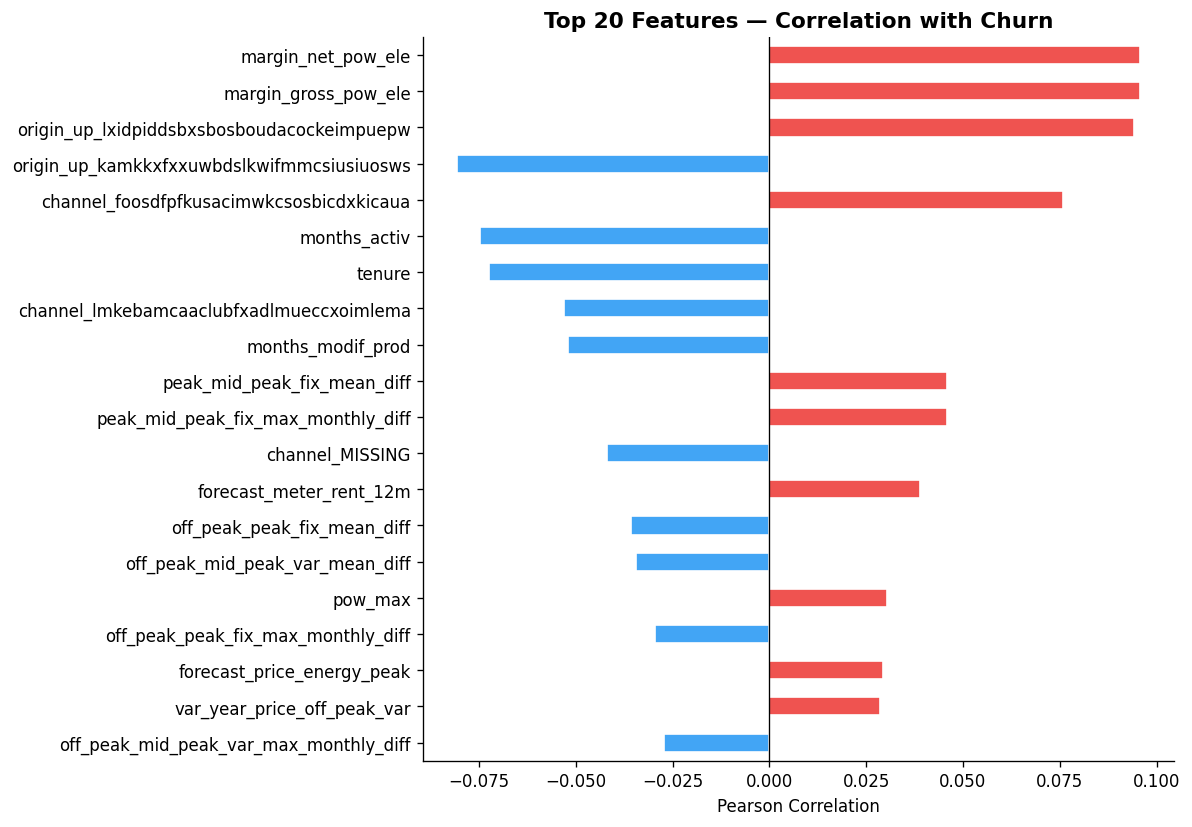

Top 10 by |correlation|:
                                            correlation
margin_net_pow_ele                               0.0958
margin_gross_pow_ele                             0.0957
origin_up_lxidpiddsbxsbosboudacockeimpuepw       0.0941
origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws      -0.0808
channel_foosdfpfkusacimwkcsosbicdxkicaua         0.0760
months_activ                                    -0.0748
tenure                                          -0.0724
channel_lmkebamcaaclubfxadlmueccxoimlema        -0.0529
months_modif_prod                               -0.0521
peak_mid_peak_fix_mean_diff                      0.0459


In [16]:
# ── Top 20 features correlated with churn ────────────────────────────────────
corr_churn = (
    df.select_dtypes(include=[np.number])
    .corr()['churn']
    .drop('churn')
    .sort_values(key=abs, ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#EF5350' if v > 0 else '#42A5F5' for v in corr_churn.values]
corr_churn.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Features — Correlation with Churn', fontweight='bold', fontsize=13)
ax.set_xlabel('Pearson Correlation')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 by |correlation|:')
print(corr_churn.head(10).to_frame('correlation').round(4))

## 8. Export Final Dataset

In [17]:
OUTPUT_PATH = './data_for_predictions.csv'
df.to_csv(OUTPUT_PATH, index=False)

print(f'✅  Saved → {OUTPUT_PATH}')
print(f'   Shape  : {df.shape}')
print(f'   Churn  : {df["churn"].mean() * 100:.2f}%')
df.head(3)

✅  Saved → ./data_for_predictions.csv
   Shape  : (14606, 63)
   Churn  : 9.72%


,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,pow_max,var_year_price_off_peak_var,var_year_price_peak_var,var_year_price_mid_peak_var,var_year_price_off_peak_fix,var_year_price_peak_fix,var_year_price_mid_peak_fix,var_year_price_off_peak,var_year_price_peak,var_year_price_mid_peak,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power,off_peak_peak_var_mean_diff,peak_mid_peak_var_mean_diff,off_peak_mid_peak_var_mean_diff,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff,off_peak_peak_var_max_monthly_diff,peak_mid_peak_var_max_monthly_diff,off_peak_mid_peak_var_max_monthly_diff,off_peak_peak_fix_max_monthly_diff,peak_mid_peak_fix_max_monthly_diff,off_peak_mid_peak_fix_max_monthly_diff,tenure,months_activ,months_to_end,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.0000,10.9141,0.0000,0.0000,0.0000,1.0225,0.1145,0.0981,40.6067,1,0.0000,25.4400,25.4400,2,6.5221,43.6480,0.0001,0.0000,0.0004,1.1028,49.5507,22.0225,1.1028,49.5507,22.0230,0.0001,0.0000,0.0009,2.0863,99.5305,44.2358,2.0864,99.5306,44.2367,1,0.0201,3.7010,0.0240,0.0342,0.0583,18.5903,7.4507,26.0409,0.0605,0.0855,0.1460,44.2669,8.1458,44.2669,3,30,5,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,8.4470,0.0000,0.0000,5.2520,0.0000,2.8490,0.1457,0.0000,44.3114,0,0.0000,16.3800,16.3800,1,2.9902,13.8000,0.0000,0.0006,0.0000,0.0065,0.0000,0.0000,0.0065,0.0006,0.0000,0.0000,0.0012,0.0000,0.0095,0.0000,0.0000,0.0095,0.0012,0.0000,0,-0.0038,0.1778,0.1425,0.0071,0.1496,44.3114,0.0000,44.3114,0.1514,0.0855,0.1514,44.4447,0.0000,44.4447,7,76,7,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,6.3008,0.0000,0.0000,3.8910,0.0000,3.6819,0.1658,0.0879,44.3114,0,0.0000,28.6000,28.6000,1,2.0281,13.8560,0.0000,0.0000,0.0000,0.0077,0.0000,0.0000,0.0077,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,-0.0047,0.1778,0.0821,0.0884,0.1705,44.3855,0.0000,44.3855,0.0846,0.0892,0.1725,44.4447,0.0000,44.4447,6,68,3,68,8,0,0,1,0,0,1,0,0


### ✅ Feature Engineering Complete

| Category | Features Created |
|---|---|
| Dec–Jan off-peak diff | `offpeak_diff_dec_january_energy`, `offpeak_diff_dec_january_power` |
| Mean period diffs | 6 × `*_mean_diff` (var & fix, all period pairs) |
| Max monthly diffs | 6 × `*_max_monthly_diff` |
| Log-transforms | 7 skewed columns transformed with `log1p` |
| Date / Tenure | `tenure`, `months_activ`, `months_to_end`, `months_modif_prod`, `months_renewal` |
| Categorical | `has_gas`, 5× channel dummies, 3× origin_up dummies |

**Next step → Task 5 Predictive Modelling** using `data_for_predictions.csv`